In [1]:
import tensorflow as tf
tf.keras.backend.clear_session()


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import cv2
import os
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Input, Conv2D
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
# from tensorflow.keras.applications import preprocess_input
from tensorflow.keras import layers, models, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2

In [3]:
import tensorflow as tf

# Check if GPU is available
if tf.config.list_physical_devices('GPU'):
    print("Using GPU")
else:
    print("Using CPU")

print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Using GPU
Num GPUs Available:  2


In [4]:
disease_types = ['Cirrhosis', 'No Fibrosis', 'Periportal Fibrosis','Portal Fibrosis','Septal Fibrosis']
data_dir = '/kaggle/input/resized-dataset256-lung-disease-raw/Resized_Dataset'
train_dir = os.path.join(data_dir)
# test_dir = os.path.join(data_dir, 'test')

In [5]:
train_data = []
for defects_id, sp in enumerate(disease_types):
    for file in os.listdir(os.path.join(train_dir, sp)):
        train_data.append(['{}/{}'.format(sp, file), defects_id, sp])

train = pd.DataFrame(train_data, columns=['File', 'DiseaseID','Disease Type'])
train.head(3)

,File,DiseaseID,Disease Type
0,Cirrhosis/d17.jpg,0,Cirrhosis
1,Cirrhosis/i7696.jpg,0,Cirrhosis
2,Cirrhosis/s9859.jpg,0,Cirrhosis


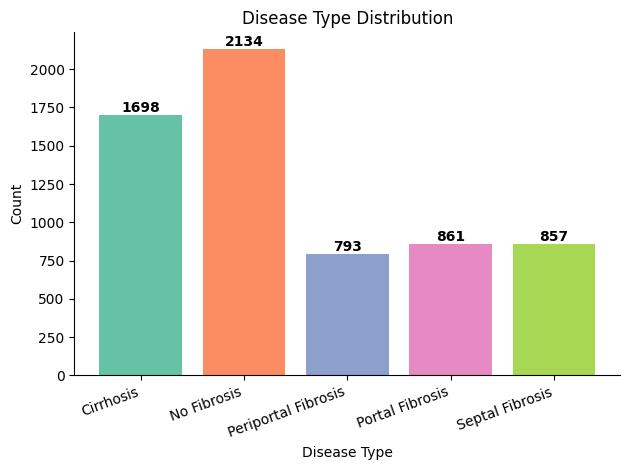

In [6]:
from matplotlib import pyplot as plt
import seaborn as sns

# Calculate the counts for each disease type
counts = train.groupby('Disease Type').size()

# Create the vertical bar chart
fig, ax = plt.subplots()
ax.bar(counts.index, counts, color=sns.color_palette('Set2', len(counts)))  # Use Set2 palette for soft colors

# Add labels and title
ax.set_xlabel('Disease Type')
ax.set_ylabel('Count')
ax.set_title('Disease Type Distribution')

# Annotate each bar with the count
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.2, f'{int(p.get_height())}',
            ha='center', va='bottom', color='black', fontweight='bold')

# Remove top and right spines for cleaner aesthetics
ax.spines[['top', 'right']].set_visible(False)

# Show the plot
plt.xticks(rotation=20, ha='right')  # Rotate the x-axis labels for readability
plt.tight_layout()  # Adjust layout for tight display
plt.show()

In [7]:
len(train_data)

6343

In [8]:
# Randomize the order of training set
SEED = 42
train = train.sample(frac=1, random_state=SEED)
train.index = np.arange(len(train)) # Reset indices
train.head(5)

,File,DiseaseID,Disease Type
0,Cirrhosis/M6532.jpg,0,Cirrhosis
1,Portal Fibrosis/h5783.jpg,3,Portal Fibrosis
2,Portal Fibrosis/d482.jpg,3,Portal Fibrosis
3,Periportal Fibrosis/q201.jpg,2,Periportal Fibrosis
4,Cirrhosis/ct15-21.png,0,Cirrhosis


In [9]:
IMAGE_SIZE = 256
SEED = 42

def read_image(filepath):
    return cv2.imread(os.path.join(data_dir, filepath))

In [10]:
X_train = np.zeros((train.shape[0], IMAGE_SIZE, IMAGE_SIZE, 3))  
for i, file in tqdm(enumerate(train['File'].values)):
    image = read_image(file)
    if image is not None:
        X_train[i] = image
X_train = X_train / 255.0

6343it [00:40, 156.14it/s]


In [11]:
print('Train Shape: {}'.format(X_train.shape))
Y_train = train['DiseaseID'].values
Y_train = to_categorical(Y_train, num_classes=len(disease_types))

Train Shape: (6343, 256, 256, 3)


In [12]:
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.3, random_state=SEED)

In [13]:
SIZE=256
N_ch=3

In [14]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import tensorflow as tf

def build_resnet():
    resnet = ResNet50V2(weights="imagenet", 
                         include_top=False, input_shape=(SIZE, SIZE, N_ch))

    for layer in resnet.layers[-30:]:
        layer.trainable = True

    input_layer = Input(shape=(SIZE, SIZE, N_ch))

    x = Conv2D(3, (3, 3), padding='same', activation='relu')(input_layer)
    x = resnet(x)
    x = Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    x = GlobalAveragePooling2D()(x)    

    x = Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.6)(x)
    
    x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.6)(x)

    output = Dense(5, kernel_regularizer=l2(0.01), activation='softmax', name='root')(x)

    model = Model(input_layer, output)

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=1e-4,
        decay_steps=1000,
        decay_rate=0.9
    )

    optimizer = Adam(learning_rate=lr_schedule)

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=1e-5),
        metrics=['accuracy']  
    )

    return model

# Build the model
model = build_resnet()


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 256, 256, 3)         │              84 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50v2 (Functional)              │ (None, 8, 8, 2048)          │      23,564,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 8, 8, 256)           │       4,718,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │         263,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ root (Dense)                         │ (None, 5)                   │           2,565 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,081,433 (110.94 MB)

 Trainable params: 29,032,409 (110.75 MB)

 Non-trainable params: 49,024 (191.50 KB)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
annealer = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, verbose=5, min_lr=1e-3)
checkpoint = ModelCheckpoint('/kaggle/working/resnet50v2.keras', monitor='val_accuracy', save_best_only=True)


In [17]:
import tensorflow as tf
import math

tf.keras.backend.clear_session()

batch_size = 16  

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, Y_train))
    .shuffle(buffer_size=len(X_train))
    .batch(batch_size, drop_remainder=True) 
    .prefetch(tf.data.AUTOTUNE)
    .repeat()
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_val, Y_val))
    .shuffle(buffer_size=len(X_val))  
    .batch(batch_size, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

steps_per_epoch = math.ceil(len(X_train) / batch_size)
validation_steps = math.ceil(len(X_val) / batch_size)

# Train the model
EPOCHS = 100
history = model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    verbose=2,
    callbacks=[early_stopping, annealer, checkpoint],
    validation_data=val_dataset,
    validation_steps=validation_steps
)

Epoch 1/100
278/278 - 142s - 510ms/step - accuracy: 0.3309 - loss: 13.2632 - val_accuracy: 0.3400 - val_loss: 12.4354 - learning_rate: 1.0000e-05
Epoch 2/100
278/278 - 55s - 198ms/step - accuracy: 0.4881 - loss: 12.5518 - learning_rate: 1.0000e-05
Epoch 3/100


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)
/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/callback_list.py:96: UserWarning: Learning rate reduction is conditioned on metric `val_accuracy` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/model_checkpoint.py:206: UserWarning: Can save best model only with val_accuracy available, skipping.
  self

278/278 - 63s - 228ms/step - accuracy: 0.5857 - loss: 12.2345 - val_accuracy: 0.7662 - val_loss: 11.4476 - learning_rate: 1.0000e-05
Epoch 4/100
278/278 - 55s - 199ms/step - accuracy: 0.6509 - loss: 11.9475 - learning_rate: 1.0000e-05
Epoch 5/100
278/278 - 63s - 228ms/step - accuracy: 0.7037 - loss: 11.6846 - val_accuracy: 0.8518 - val_loss: 11.1564 - learning_rate: 1.0000e-05
Epoch 6/100
278/278 - 55s - 199ms/step - accuracy: 0.7516 - loss: 11.4814 - learning_rate: 1.0000e-05
Epoch 7/100
278/278 - 64s - 229ms/step - accuracy: 0.7970 - loss: 11.2739 - val_accuracy: 0.8965 - val_loss: 10.9147 - learning_rate: 1.0000e-05
Epoch 8/100
278/278 - 55s - 199ms/step - accuracy: 0.8195 - loss: 11.1480 - learning_rate: 1.0000e-05
Epoch 9/100
278/278 - 64s - 230ms/step - accuracy: 0.8473 - loss: 10.9905 - val_accuracy: 0.9301 - val_loss: 10.6977 - learning_rate: 1.0000e-05
Epoch 10/100
278/278 - 55s - 198ms/step - accuracy: 0.8905 - loss: 10.7785 - learning_rate: 1.0000e-05
Epoch 11/100
278/278 - 

In [18]:
# model = load_model('../output/kaggle/working/model.h5')
final_loss, final_accuracy = model.evaluate(X_val, Y_val)
print('Final Loss: {}, Final Accuracy: {}'.format(final_loss, final_accuracy))

60/60 ━━━━━━━━━━━━━━━━━━━━ 17s 126ms/step - accuracy: 0.9715 - loss: 1.0460
Final Loss: 1.0522834062576294, Final Accuracy: 0.9684708118438721


60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step


Text(0.5, 192.72222222222217, 'Predicted')

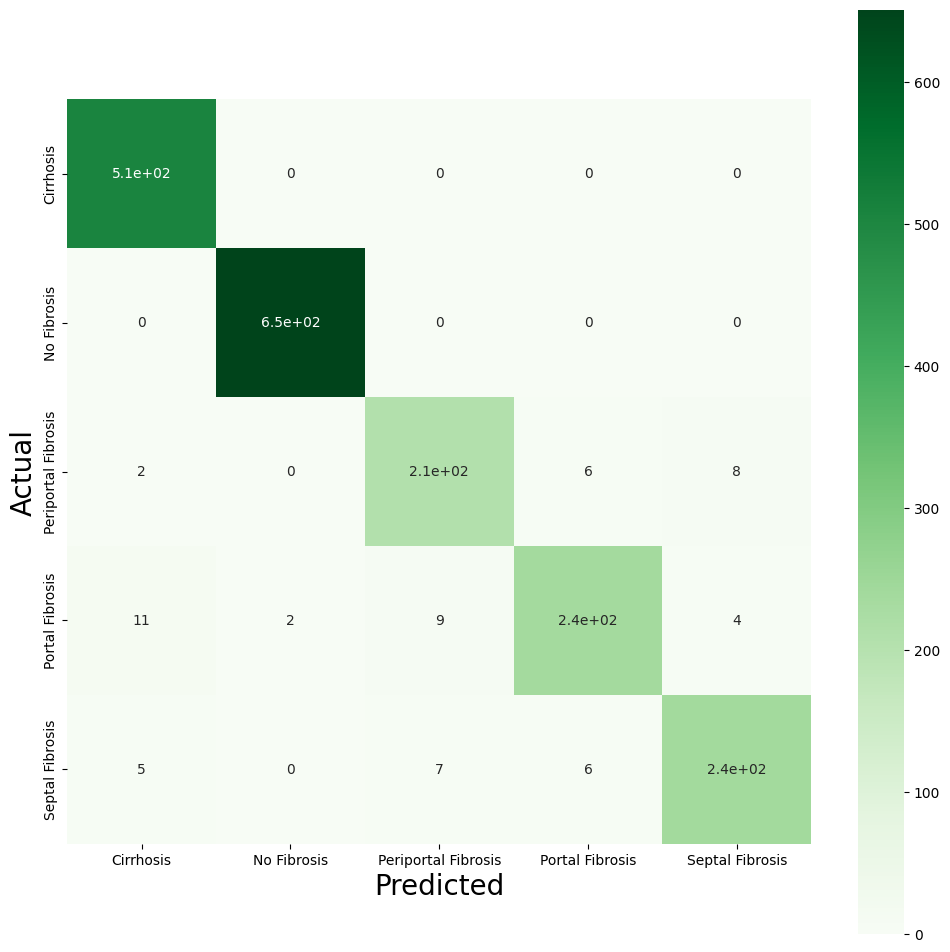

In [19]:
Y_pred = model.predict(X_val)

Y_pred = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_val, axis=1)

cm = confusion_matrix(Y_true, Y_pred)
plt.figure(figsize=(12, 12))
ax = sns.heatmap(cm, cmap=plt.cm.Greens, annot=True, square=True, xticklabels=disease_types, yticklabels=disease_types)
ax.set_ylabel('Actual', fontsize=20)
ax.set_xlabel('Predicted', fontsize=20)

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
report = classification_report(Y_true, Y_pred, target_names=disease_types)
print(report)

                     precision    recall  f1-score   support

          Cirrhosis       0.97      1.00      0.98       508
        No Fibrosis       1.00      1.00      1.00       651
Periportal Fibrosis       0.93      0.93      0.93       223
    Portal Fibrosis       0.95      0.90      0.93       263
    Septal Fibrosis       0.95      0.93      0.94       258

           accuracy                           0.97      1903
          macro avg       0.96      0.95      0.96      1903
       weighted avg       0.97      0.97      0.97      1903



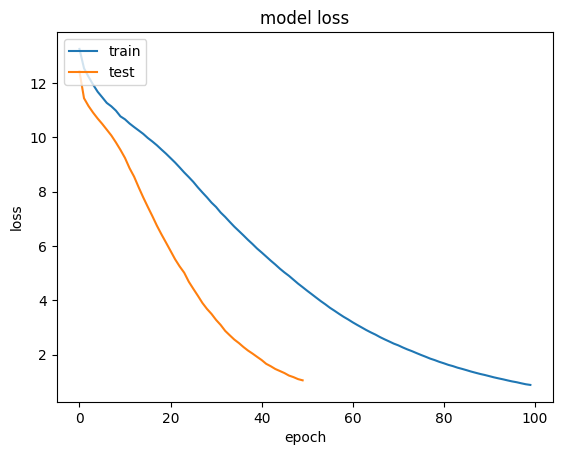

In [21]:
# loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [22]:
cm = confusion_matrix(Y_true, Y_pred)

sensitivity = {}
specificity = {}

for i, disease in enumerate(disease_types):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    
    sensitivity[disease] = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity[disease] = TN / (TN + FP) if (TN + FP) > 0 else 0

print("\nSensitivity (Recall) per Class:")
for disease, value in sensitivity.items():
    print(f"{disease}: {value:.4f}")

print("\nSpecificity per Class:")
for disease, value in specificity.items():
    print(f"{disease}: {value:.4f}")



Sensitivity (Recall) per Class:
Cirrhosis: 1.0000
No Fibrosis: 1.0000
Periportal Fibrosis: 0.9283
Portal Fibrosis: 0.9011
Septal Fibrosis: 0.9302

Specificity per Class:
Cirrhosis: 0.9871
No Fibrosis: 0.9984
Periportal Fibrosis: 0.9905
Portal Fibrosis: 0.9927
Septal Fibrosis: 0.9927
